In [13]:
import pandas as pd
import os
from pathlib import Path

experiment_logs_path = Path(r"logs\AllScenarios")

results_df = pd.read_csv(experiment_logs_path / "metrics_per_image.csv")
# results_df = pd.read_csv(experiment_logs_path / "metrics_per_image_best_model.csv")

results_df

,Architecture,Encoder,Pretrained,Participant,File,Dice,IoU
0,unet,efficientnet-b0,scratch-small,65,0.png,0.973321,0.948029
1,unet,efficientnet-b0,scratch-small,65,1.png,0.976137,0.953386
2,unet,efficientnet-b0,scratch-small,65,10.png,0.927676,0.865107
3,unet,efficientnet-b0,scratch-small,65,11.png,0.964559,0.931544
4,unet,efficientnet-b0,scratch-small,65,12.png,0.947852,0.900874
...,...,...,...,...,...,...,...
487251,unet++,mobileone_s1,scratch-small,99,5.png,0.912794,0.839578
487252,unet++,mobileone_s1,scratch-small,99,6.png,0.802163,0.669676
487253,unet++,mobileone_s1,scratch-small,99,7.png,0.813186,0.685184
487254,unet++,mobileone_s1,scratch-small,99,8.png,0.850296,0.739578


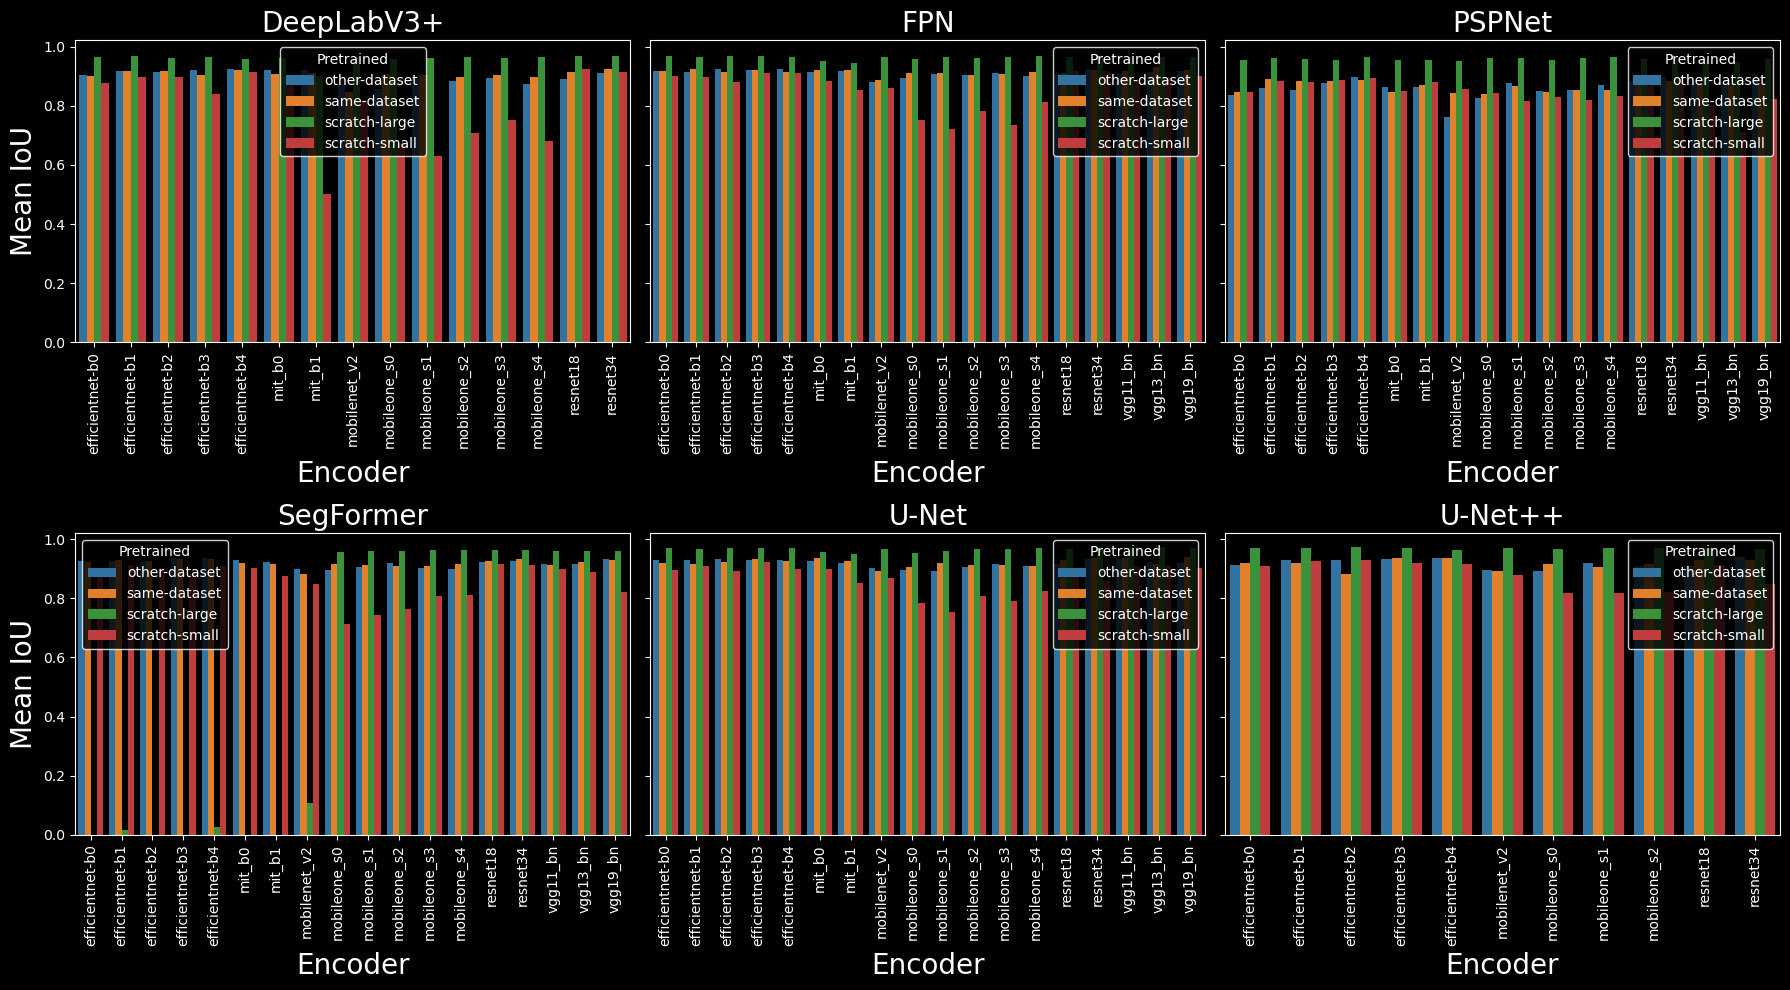

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "figure.facecolor": "black",
    "axes.facecolor": "black",
    "savefig.facecolor": "black",
    "text.color": "white",
    "axes.labelcolor": "white",
    "axes.edgecolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
})

plot_df = (
    results_df
    .groupby(["Architecture", "Encoder", "Pretrained"])
    .agg(
        mean_iou=("IoU", "mean"),
        std_iou=("IoU", "std"),
        n=("IoU", "count")
    )
    .reset_index()
)



rename_architecture = {
    "unet": "U-Net",
    "deeplabv3+": "DeepLabV3+",
    "fpn": "FPN",
    "pspnet": "PSPNet",
    "segformer": "SegFormer",
    "unet++": "U-Net++",
}

plot_df["ci95"] = 1.96 * plot_df["std_iou"] / np.sqrt(plot_df["n"])

architectures = plot_df["Architecture"].unique()

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18, 10),
    sharey=True,
    facecolor="black"
)

axes = axes.flatten()

plot_df.rename(columns={"mean_iou": "Mean IoU", "std_iou": "Std IoU", "n": "Count"}, inplace=True)

fontsize = 20

for ax, arch in zip(axes, architectures):

    tmp = plot_df[plot_df["Architecture"] == arch]

    sns.barplot(
        data=tmp,
        x="Encoder",
        y="Mean IoU",
        hue="Pretrained",
        ax=ax,
        errorbar=None
    )

    ax.set_title(rename_architecture.get(arch, arch), color="white", fontsize=fontsize)
    ax.set_xlabel(ax.get_xlabel(), color="white", fontsize=fontsize)
    ax.set_ylabel(ax.get_ylabel(), color="white", fontsize=fontsize)
    ax.tick_params(axis="x", rotation=90, colors="white")
    ax.tick_params(axis="y", colors="white")
    ax.spines[:].set_color("white")

    legend = ax.get_legend()
    if legend is not None:
        legend.get_frame().set_facecolor("black")
        legend.get_frame().set_edgecolor("white")
        for text in legend.get_texts():
            text.set_color("white")
        legend.get_title().set_color("white")

plt.tight_layout()
plt.show()

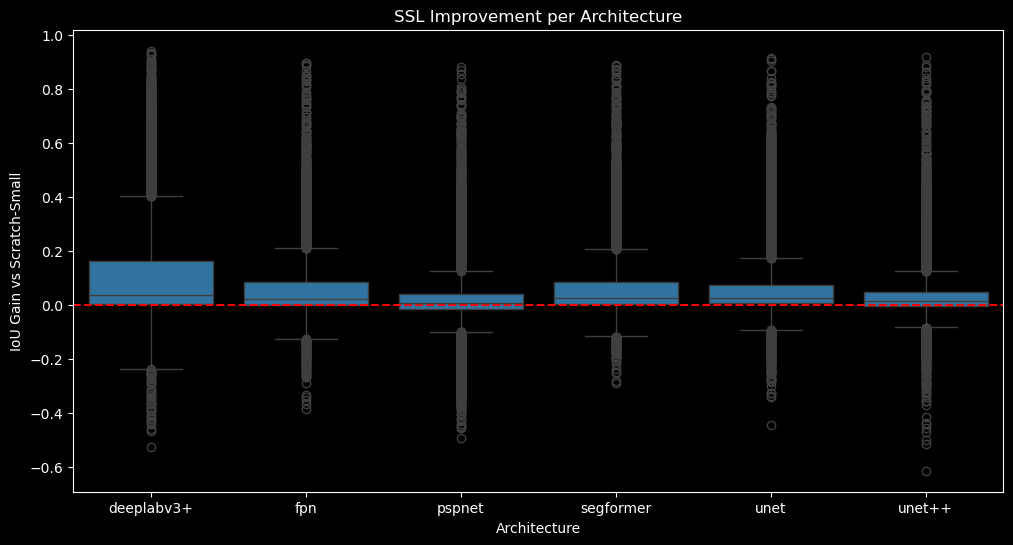

In [15]:
results_iou = results_df.pivot_table(
    index=["Architecture", "Encoder", "Participant", "File"],
    columns="Pretrained",
    values="IoU"
)

results_iou["gain_same"] = (
    results_iou["same-dataset"]
    - results_iou["scratch-small"]
)

results_iou["gain_other"] = (
    results_iou["other-dataset"]
    - results_iou["scratch-small"]
)

gains = results_iou.reset_index()

fig, ax = plt.subplots(figsize=(12,6))

sns.boxplot(
    data=gains,
    x="Architecture",
    y="gain_same",
    ax=ax
)

ax.axhline(
    0,
    color="red",
    linestyle="--"
)

ax.set_ylabel("IoU Gain vs Scratch-Small")
ax.set_title("SSL Improvement per Architecture")

plt.show()

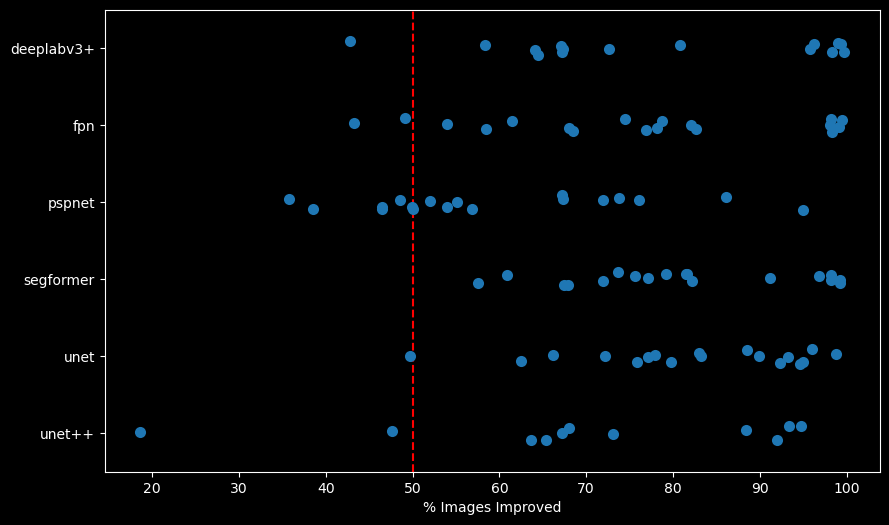

In [16]:
summary = []

for (arch, encoder), group in gains.groupby(
    ["Architecture", "Encoder"]
):

    pct_improved = (
        group["gain_same"] > 0
    ).mean() * 100

    summary.append(
        {
            "Architecture": arch,
            "Encoder": encoder,
            "ImprovedPercent": pct_improved
        }
    )

improved_df = pd.DataFrame(summary)

plt.figure(figsize=(10,6))

sns.stripplot(
    data=improved_df,
    x="ImprovedPercent",
    y="Architecture",
    size=8
)

plt.axvline(50, color="red", linestyle="--")

plt.xlabel("% Images Improved")
plt.ylabel("")
plt.show()



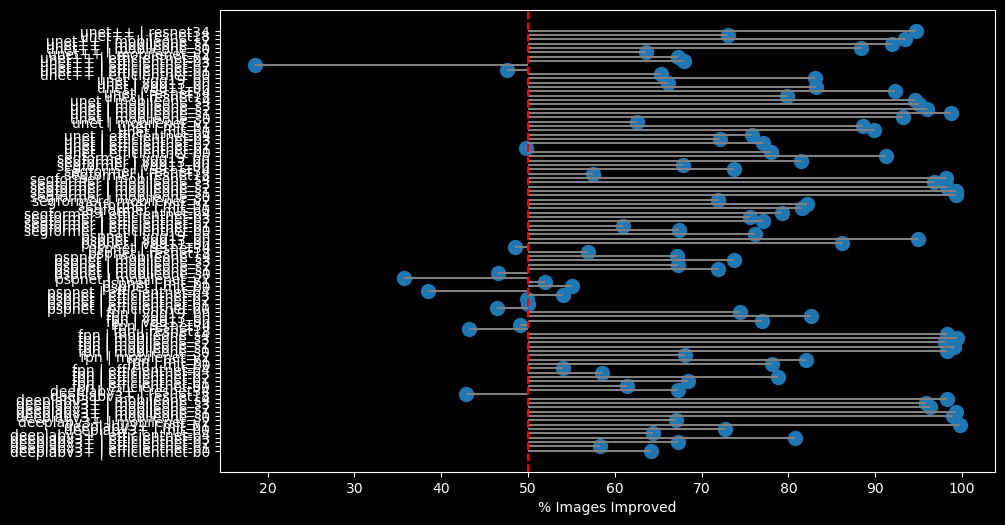

In [17]:
tmp = improved_df.sort_values("ImprovedPercent")

plt.figure(figsize=(10,6))

plt.hlines(
    y=tmp.index,
    xmin=50,
    xmax=tmp["ImprovedPercent"],
    color="gray"
)

plt.scatter(
    tmp["ImprovedPercent"],
    tmp.index,
    s=100
)

plt.axvline(50, ls="--", c="red")

plt.yticks(tmp.index, tmp["Architecture"] + " | " + tmp["Encoder"])

plt.xlabel("% Images Improved")
plt.show()

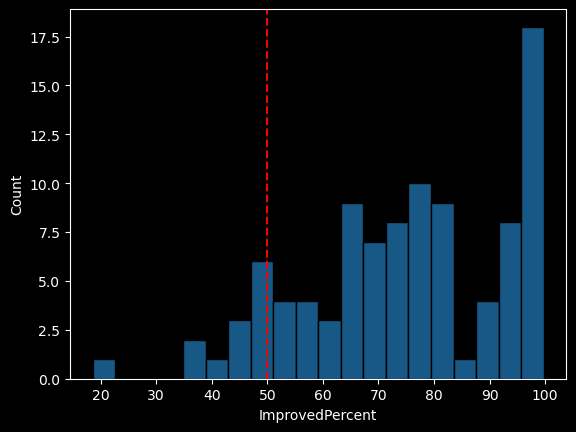

In [18]:
sns.histplot(
    improved_df["ImprovedPercent"],
    bins=20
)

plt.axvline(
    50,
    color="red",
    linestyle="--"
)

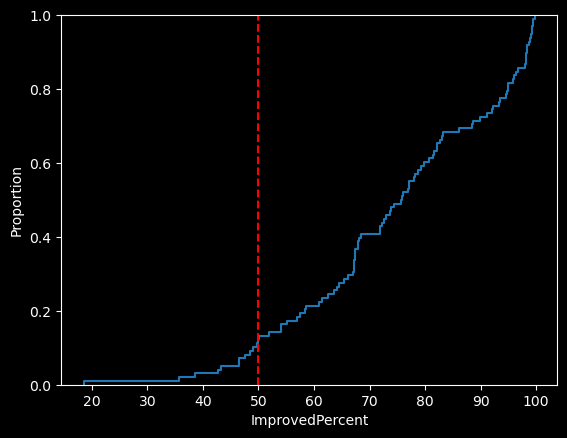

In [19]:
sns.ecdfplot(
    improved_df["ImprovedPercent"]
)

plt.axvline(
    50,
    color="red",
    linestyle="--"
)

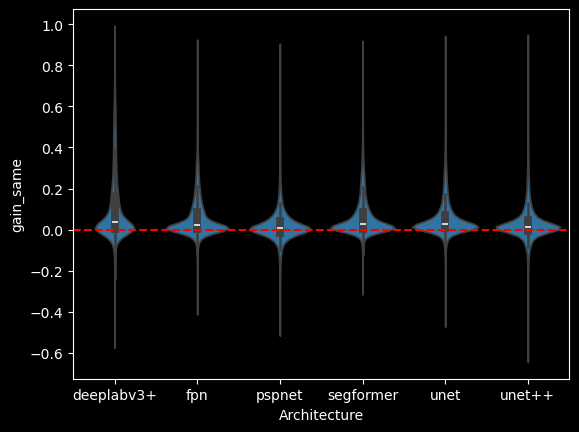

In [20]:
sns.violinplot(
    data=gains.reset_index(),
    x="Architecture",
    y="gain_same"
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)
plt.show()

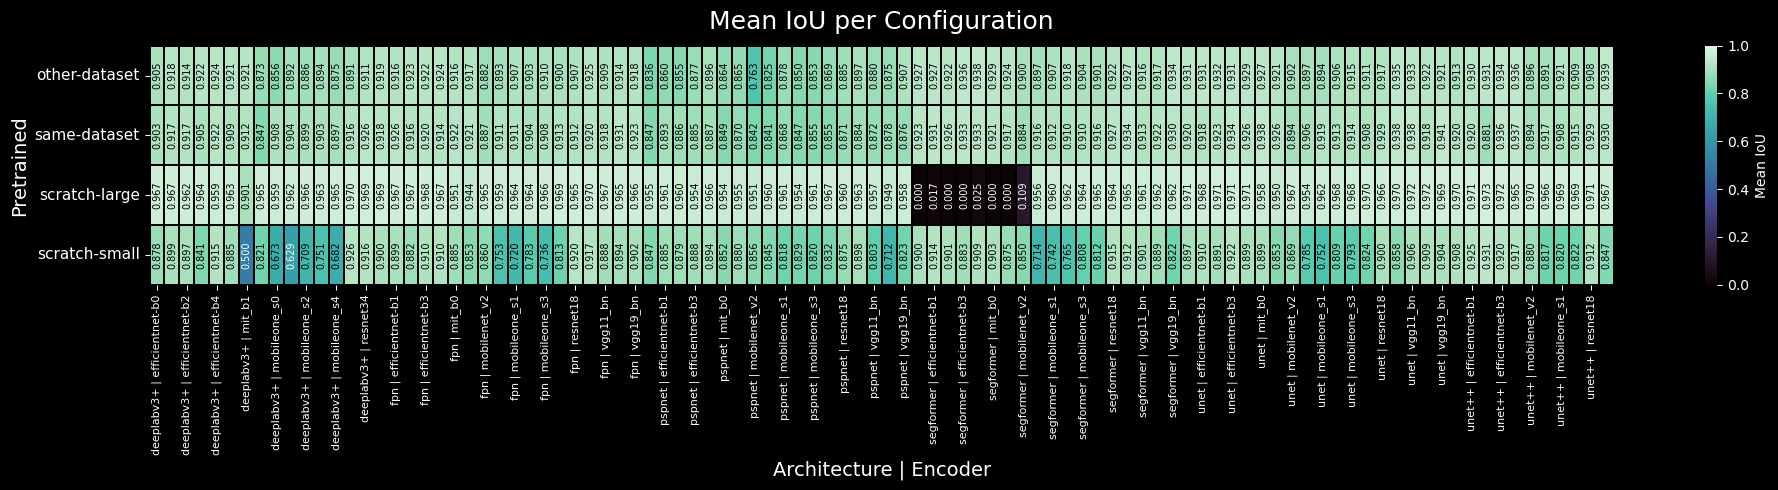

In [ ]:
heatmap_df = (
    results_df
    .groupby(
        ["Architecture", "Encoder", "Pretrained"]
    )["IoU"]
    .mean()
    .reset_index()
)

heatmap_df["Row"] = (
    heatmap_df["Architecture"]
    + " | "
    + heatmap_df["Encoder"]
)

heatmap_data = heatmap_df.pivot(
    index="Pretrained",
    columns="Row",
    values="IoU"
)

fig, ax = plt.subplots(figsize=(20, 5), facecolor="black")
ax.set_facecolor("black")

heatmap = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="mako",
    vmin=0,
    vmax=1,
    linewidths=0.25,
    linecolor="black",
    annot_kws={"color": "white", "fontsize": 7},
    ax=ax,
    cbar_kws={"label": "Mean IoU"}
)

ax.set_title("Mean IoU per Configuration", color="white", fontsize=18, pad=12)
ax.set_xlabel("Architecture | Encoder", color="white", fontsize=14)
ax.set_ylabel("Pretrained", color="white", fontsize=14)
ax.set_xticks(np.arange(len(heatmap_data.columns)) + 0.5)
ax.set_xticklabels(
    heatmap_data.columns,
    color="white",
    fontsize=8,
    rotation=90,
    ha="center",
)
ax.tick_params(axis="y", colors="white", labelsize=11, rotation=0)

cell_values = heatmap_data.to_numpy().flatten()
cmap = plt.get_cmap("mako")
norm = heatmap.collections[0].norm
for text, value in zip(ax.texts, cell_values):
    background = cmap(norm(value))
    luminance = (
        0.2126 * background[0]
        + 0.7152 * background[1]
        + 0.0722 * background[2]
    )
    text.set_color("black" if luminance > 0.55 else "white")
    text.set_rotation(90)
    text.set_ha("center")
    text.set_va("center")

colorbar = heatmap.collections[0].colorbar
colorbar.ax.yaxis.label.set_color("white")
colorbar.ax.tick_params(colors="white")

plt.tight_layout()
plt.show()

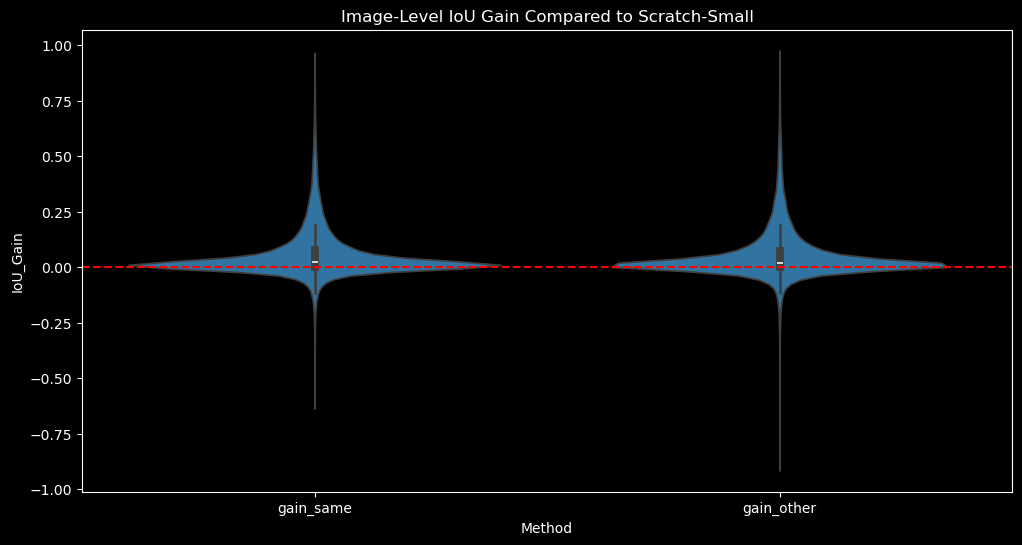

In [22]:
plot_df = gains.melt(
    id_vars=["Architecture", "Encoder"],
    value_vars=["gain_same", "gain_other"],
    var_name="Method",
    value_name="IoU_Gain"
)

plt.figure(figsize=(12,6))

sns.violinplot(
    data=plot_df,
    x="Method",
    y="IoU_Gain"
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.title(
    "Image-Level IoU Gain Compared to Scratch-Small"
)

plt.show()

In [28]:
# pivot value: Dice, column: Pretrained, index: Architecture, Encoder

results_dice = results_df.pivot_table(index=['Architecture', 'Encoder', 'Participant', 'File'], columns='Pretrained', values='Dice', aggfunc='max')

display(results_dice)

results_iou = results_df.pivot_table(index=['Architecture', 'Encoder', 'Participant', 'File'], columns='Pretrained', values='IoU', aggfunc='mean')

display(results_iou)

Pretrained                                       other-dataset  same-dataset  \
Architecture Encoder         Participant File                                  
deeplabv3+   efficientnet-b0 7           0.png        0.946854      0.958031   
                                         1.png        0.974293      0.969152   
                                         10.png       0.969906      0.971528   
                                         11.png       0.959356      0.976159   
                                         12.png       0.966027      0.967104   
...                                                        ...           ...   
unet++       resnet34        99          5.png        0.976261      0.980075   
                                         6.png        0.956155      0.958386   
                                         7.png        0.942896      0.932485   
                                         8.png        0.957917      0.972273   
                                         9.png        0.967070      0.984357   

Pretrained                                       scratch-large  scratch-small  
Architecture Encoder         Participant File                                  
deeplabv3+   efficientnet-b0 7           0.png        0.980618       0.935463  
                                         1.png        0.989459       0.912650  
                                         10.png       0.987965       0.963844  
                                         11.png       0.979861       0.932482  
                                         12.png       0.975754       0.941104  
...                                                        ...            ...  
unet++       resnet34        99          5.png        0.988153       0.946726  
                                         6.png        0.981717       0.854392  
                                         7.png        0.979360       0.796505  
                                         8.png        0.992320       0.824522  
                                         9.png        0.987085       0.753981  

[121814 rows x 4 columns]

Pretrained                                       other-dataset  same-dataset  \
Architecture Encoder         Participant File                                  
deeplabv3+   efficientnet-b0 7           0.png        0.899072      0.919442   
                                         1.png        0.949874      0.940150   
                                         10.png       0.941570      0.944632   
                                         11.png       0.921886      0.953429   
                                         12.png       0.934287      0.936304   
...                                                        ...           ...   
unet++       resnet34        99          5.png        0.953623      0.960928   
                                         6.png        0.915993      0.920097   
                                         7.png        0.891961      0.873510   
                                         8.png        0.919233      0.946042   
                                         9.png        0.936240      0.969195   

Pretrained                                       scratch-large  scratch-small  
Architecture Encoder         Participant File                                  
deeplabv3+   efficientnet-b0 7           0.png        0.961973       0.878752  
                                         1.png        0.979137       0.839333  
                                         10.png       0.976217       0.930211  
                                         11.png       0.960518       0.873504  
                                         12.png       0.952655       0.888759  
...                                                        ...            ...  
unet++       resnet34        99          5.png        0.976582       0.898841  
                                         6.png        0.964090       0.745798  
                                         7.png        0.959555       0.661826  
                                         8.png        0.984757       0.701436  
                                         9.png        0.974499       0.605112  

[121814 rows x 4 columns]

In [34]:
# Pairwise proportion of images where one pretrained option beats another
comparison_df = results_iou.copy()
pretrained_options = comparison_df.columns.tolist()
pairwise_rows = []

for index, row in comparison_df.iterrows():
    for option in pretrained_options:
        for opponent in pretrained_options:
            if option == opponent:
                continue

            option_iou = row[option]
            opponent_iou = row[opponent]
            if pd.notna(option_iou) and pd.notna(opponent_iou):
                pairwise_rows.append({
                    **dict(zip(comparison_df.index.names, index)),
                    "Pretrained": option,
                    "Opponent": opponent,
                    "Win": option_iou > opponent_iou,
                    "Tie": option_iou == opponent_iou,
                })

pairwise_comparisons_df = pd.DataFrame(pairwise_rows)

pairwise_proportion_df = (
    pairwise_comparisons_df
    .groupby(
        ["Architecture", "Encoder", "Pretrained", "Opponent"],
        as_index=False
    )
    .agg(
        Proportion=("Win", "mean"),
        Wins=("Win", "sum"),
        Comparisons=("Win", "count"),
        Ties=("Tie", "sum"),
    )
)

# Optional wide format: one row per option and one proportion column per opponent.
pairwise_proportion_wide_df = (
    pairwise_proportion_df
    .pivot(
        index=["Architecture", "Encoder", "Pretrained"],
        columns="Opponent",
        values="Proportion",
    )
    .add_prefix("vs_")
    .reset_index()
)

pairwise_proportion_wide_df

Opponent,Architecture,Encoder,Pretrained,vs_other-dataset,vs_same-dataset,vs_scratch-large,vs_scratch-small
0,deeplabv3+,efficientnet-b0,other-dataset,NaN,0.560740,0.030571,0.647627
1,deeplabv3+,efficientnet-b0,same-dataset,0.439260,NaN,0.025744,0.641191
2,deeplabv3+,efficientnet-b0,scratch-large,0.969429,0.974256,NaN,0.992759
3,deeplabv3+,efficientnet-b0,scratch-small,0.352373,0.358809,0.007241,NaN
4,deeplabv3+,efficientnet-b1,other-dataset,NaN,0.538214,0.032180,0.603379
...,...,...,...,...,...,...,...
387,unet++,resnet18,scratch-small,0.481094,0.269509,0.024135,NaN
388,unet++,resnet34,other-dataset,NaN,0.540628,0.061142,0.953339
389,unet++,resnet34,same-dataset,0.459372,NaN,0.080451,0.946903
390,unet++,resnet34,scratch-large,0.938858,0.919549,NaN,0.998391


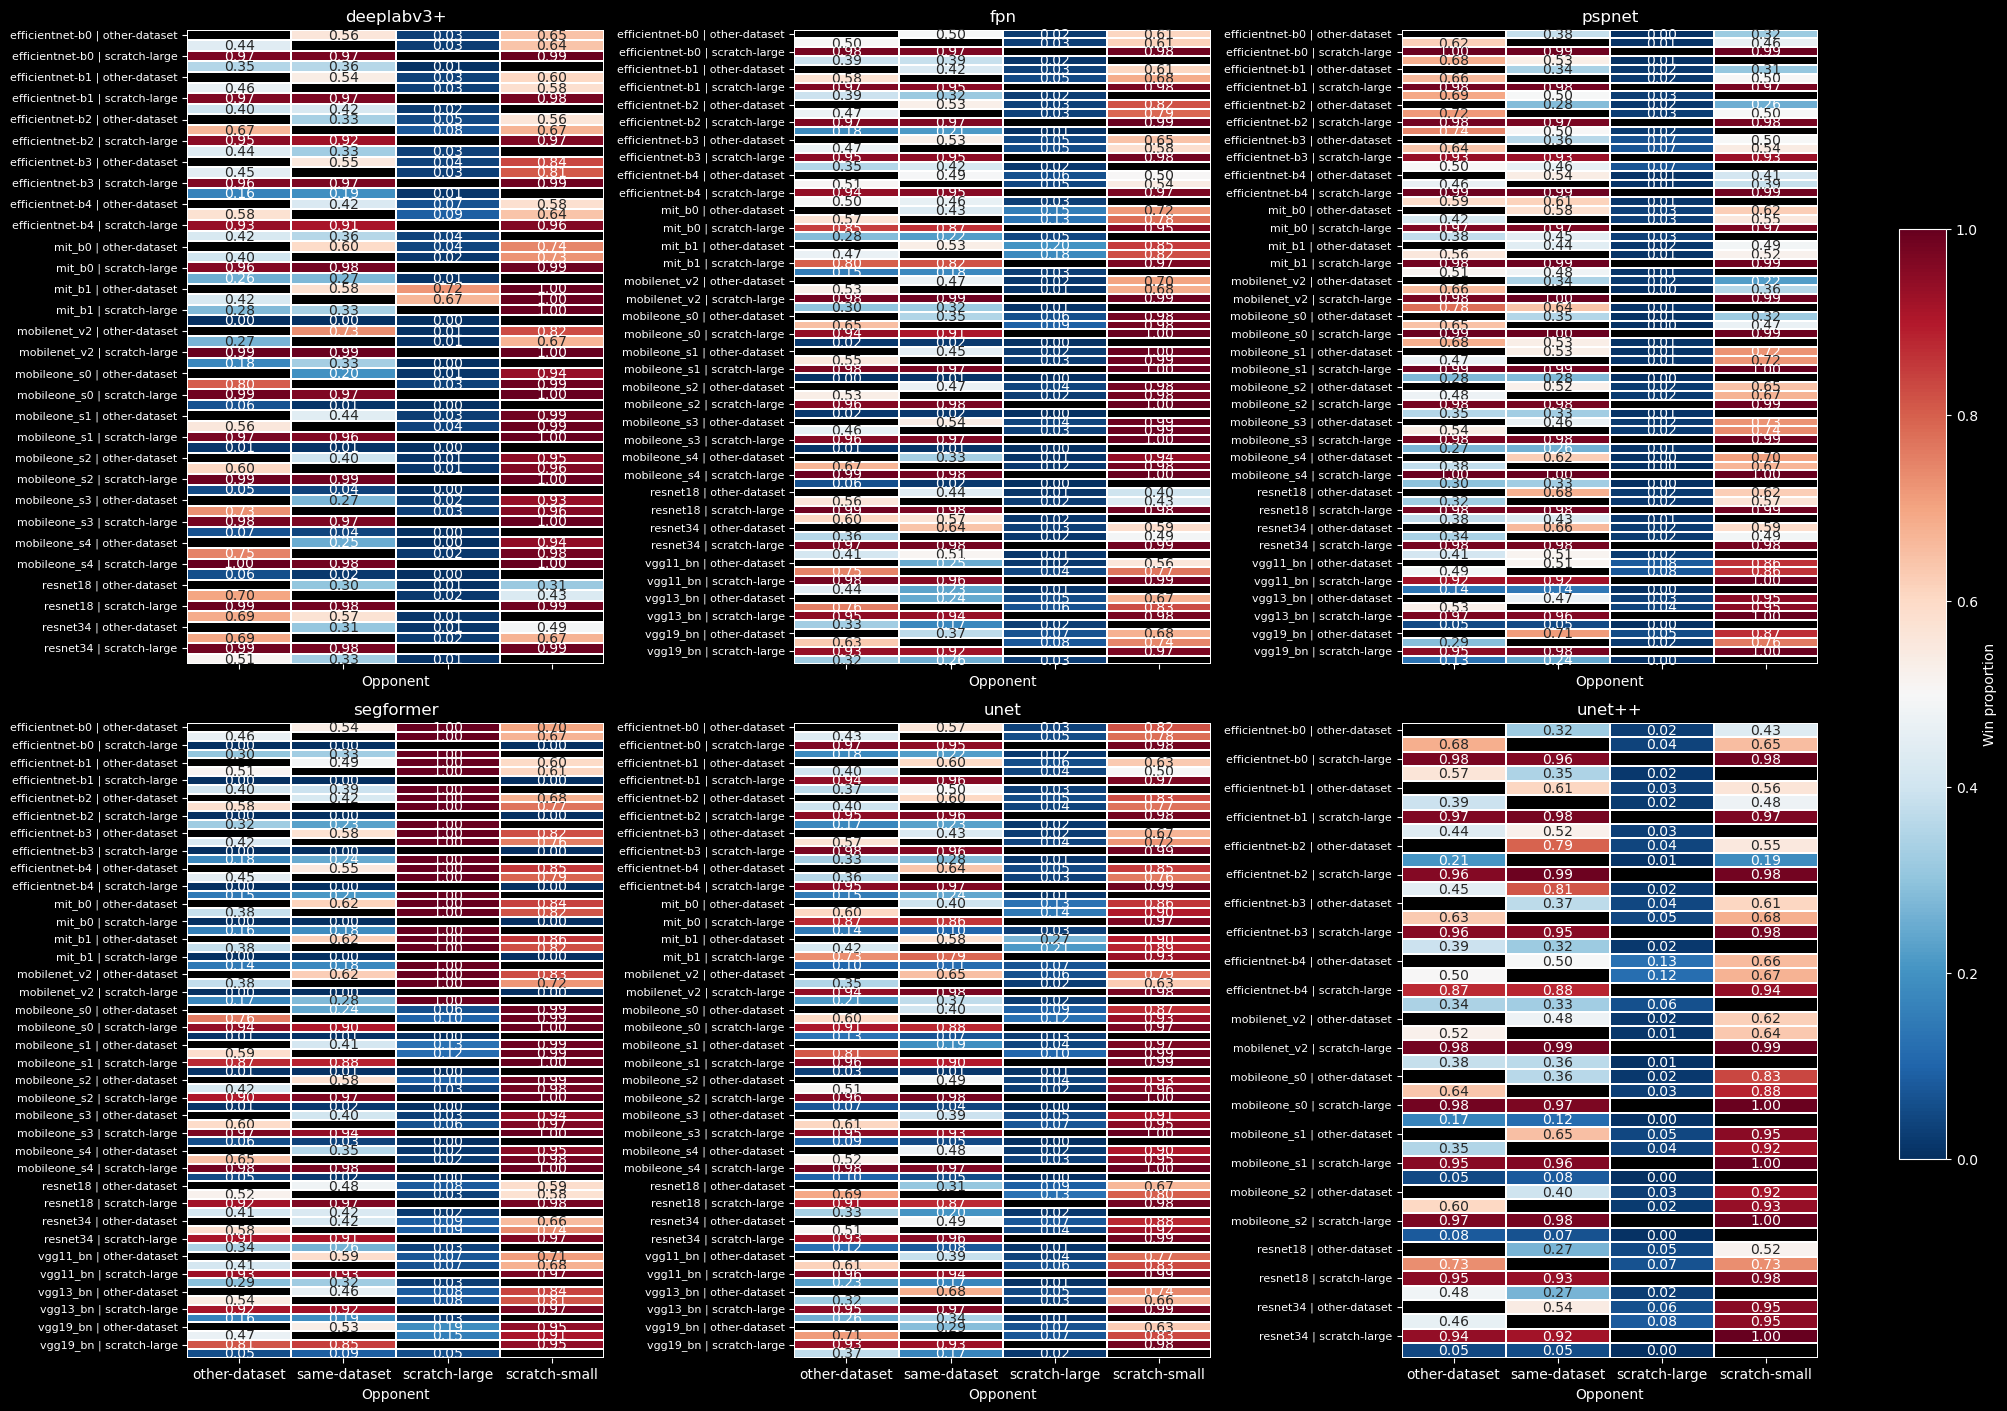

In [38]:
plot_df = pairwise_proportion_df.copy()

plot_df["Configuration"] = (
    plot_df["Encoder"]
    + " | "
    + plot_df["Pretrained"]
)

architectures = plot_df["Architecture"].unique()

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(20, 14),
    sharex=True,
    constrained_layout=True,
)

axes = axes.flatten()

for ax, architecture in zip(axes, architectures):
    data = (
        plot_df[plot_df["Architecture"] == architecture]
        .pivot(
            index="Configuration",
            columns="Opponent",
            values="Proportion"
        )
    )

    sns.heatmap(
        data,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0.5,
        vmin=0,
        vmax=1,
        linewidths=0.3,
        cbar=False
    )

    ax.set_title(architecture)
    ax.set_xlabel("Opponent")
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=8)

# Hide unused subplot axes if fewer than six architectures exist.
for ax in axes[len(architectures):]:
    ax.set_visible(False)

sm = plt.cm.ScalarMappable(
    cmap="RdBu_r",
    norm=plt.Normalize(vmin=0, vmax=1)
)
sm.set_array([])

fig.colorbar(
    sm,
    ax=axes,
    label="Win proportion",
    shrink=0.7
)

plt.show()

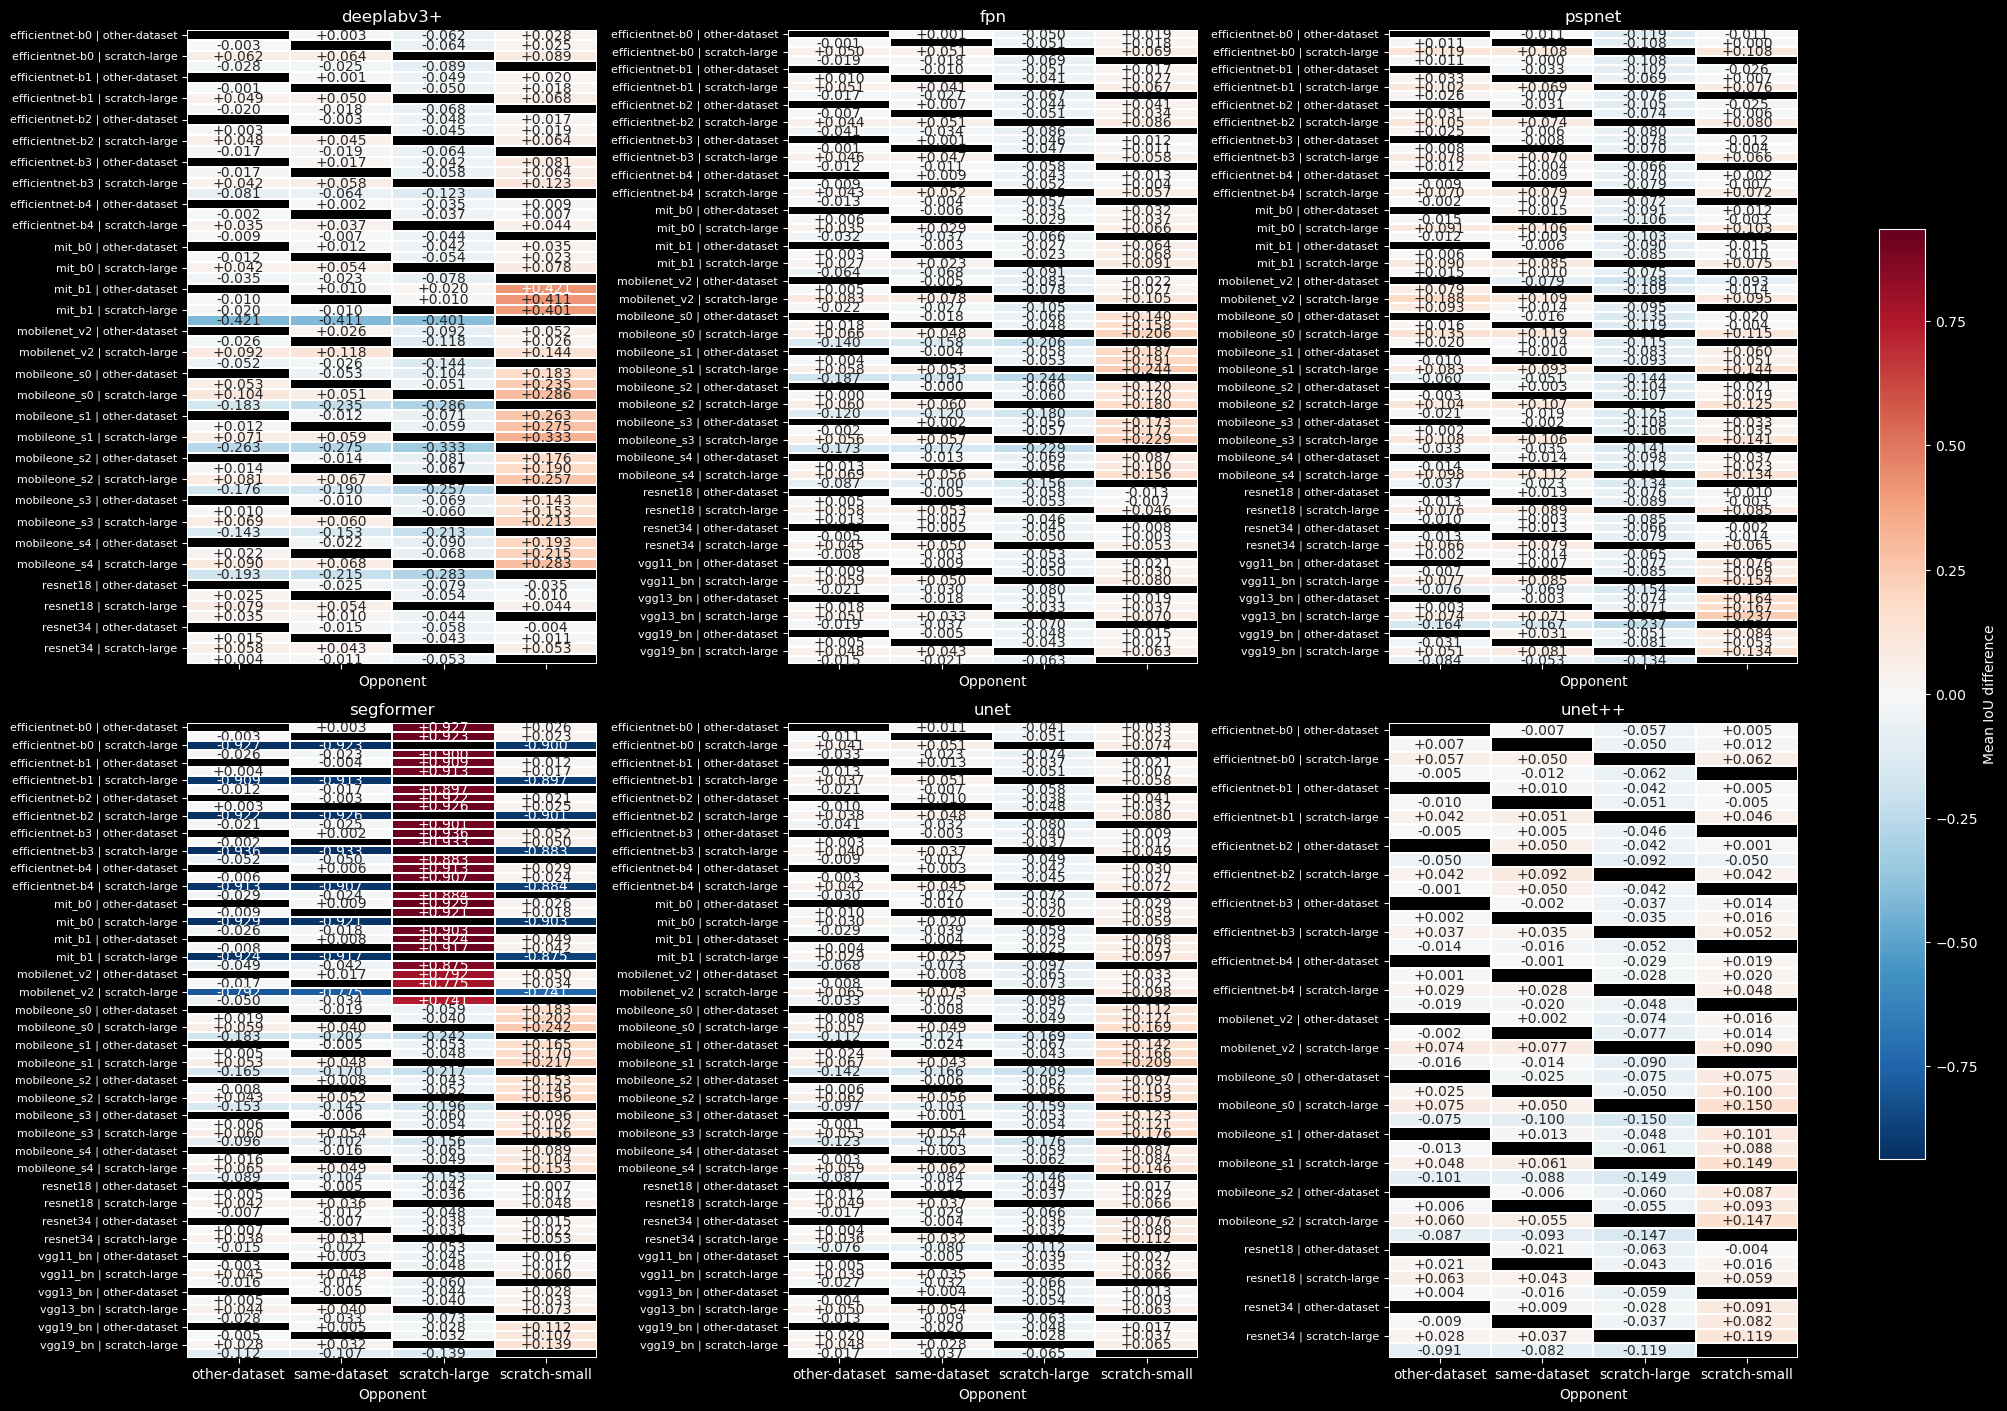

,Architecture,Encoder,Pretrained,Opponent,MeanDifference,MedianDifference,StdDifference,ProportionPositive,Comparisons
0,deeplabv3+,efficientnet-b0,other-dataset,same-dataset,0.002657,0.002659,0.044905,0.560740,1243
1,deeplabv3+,efficientnet-b0,other-dataset,scratch-large,-0.061601,-0.032654,0.089903,0.030571,1243
2,deeplabv3+,efficientnet-b0,other-dataset,scratch-small,0.027749,0.008293,0.081000,0.647627,1243
3,deeplabv3+,efficientnet-b0,same-dataset,other-dataset,-0.002657,-0.002659,0.044905,0.439260,1243
4,deeplabv3+,efficientnet-b0,same-dataset,scratch-large,-0.064259,-0.036168,0.099533,0.025744,1243
...,...,...,...,...,...,...,...,...,...
1171,unet++,resnet34,scratch-large,same-dataset,0.037318,0.016442,0.064464,0.919549,1243
1172,unet++,resnet34,scratch-large,scratch-small,0.119411,0.061639,0.152222,0.998391,1243
1173,unet++,resnet34,scratch-small,other-dataset,-0.091099,-0.045659,0.129163,0.046661,1243
1174,unet++,resnet34,scratch-small,same-dataset,-0.082093,-0.041424,0.112678,0.053097,1243


In [39]:
# check the differences
comparison_df = results_iou.copy()
pretrained_options = comparison_df.columns.tolist()
difference_rows = []

for index, row in comparison_df.iterrows():
    for option in pretrained_options:
        for opponent in pretrained_options:
            if option == opponent:
                continue

            option_iou = row[option]
            opponent_iou = row[opponent]
            if pd.notna(option_iou) and pd.notna(opponent_iou):
                difference_rows.append({
                    **dict(zip(comparison_df.index.names, index)),
                    "Pretrained": option,
                    "Opponent": opponent,
                    "IoU_Difference": option_iou - opponent_iou,
                })

iou_difference_df = pd.DataFrame(difference_rows)

iou_difference_summary_df = (
    iou_difference_df
    .groupby(
        ["Architecture", "Encoder", "Pretrained", "Opponent"],
        as_index=False
    )
    .agg(
        MeanDifference=("IoU_Difference", "mean"),
        MedianDifference=("IoU_Difference", "median"),
        StdDifference=("IoU_Difference", "std"),
        ProportionPositive=("IoU_Difference", lambda values: (values > 0).mean()),
        Comparisons=("IoU_Difference", "count"),
    )
)

# Visualize mean IoU differences for every architecture and encoder.
difference_plot_df = iou_difference_summary_df.copy()
difference_plot_df["Configuration"] = (
    difference_plot_df["Encoder"]
    + " | "
    + difference_plot_df["Pretrained"]
)

architectures = difference_plot_df["Architecture"].unique()
max_difference = difference_plot_df["MeanDifference"].abs().max()

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(20, 14),
    sharex=True,
    constrained_layout=True,
)
axes = axes.flatten()

for ax, architecture in zip(axes, architectures):
    data = (
        difference_plot_df[difference_plot_df["Architecture"] == architecture]
        .pivot(
            index="Configuration",
            columns="Opponent",
            values="MeanDifference"
        )
    )

    sns.heatmap(
        data,
        ax=ax,
        annot=True,
        fmt="+.3f",
        cmap="RdBu_r",
        center=0,
        vmin=-max_difference,
        vmax=max_difference,
        linewidths=0.3,
        cbar=False,
    )

    ax.set_title(architecture)
    ax.set_xlabel("Opponent")
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=8)

for ax in axes[len(architectures):]:
    ax.set_visible(False)

sm = plt.cm.ScalarMappable(
    cmap="RdBu_r",
    norm=plt.Normalize(vmin=-max_difference, vmax=max_difference),
)
sm.set_array([])
fig.colorbar(sm, ax=axes, label="Mean IoU difference", shrink=0.7)

plt.show()

iou_difference_summary_df